
# From The Met to Central Park Attractions  
## Comparing Euclidean and Pedestrian Network Distance

**Assignment: Networks**

This notebook defines Central Park's pedestrian circulation system as a spatial network and compares two ways of measuring distance from **The Metropolitan Museum of Art Fifth Avenue entrance** to twelve major Central Park attractions:

1. **Euclidean distance** — the straight-line distance between two geographic points.
2. **Pedestrian network distance** — the shortest distance that a visitor can actually walk along mapped pedestrian paths and streets.

The analysis uses OpenStreetMap pedestrian-network data through OSMnx and calculates shortest paths with NetworkX.



## Research Statement

**Research question**

> How does Central Park's pedestrian path network change the experienced distance between The Metropolitan Museum of Art and major attractions within the park?

Although many Central Park attractions appear close to The Met on a map, visitors cannot move through the landscape in straight lines. The museum building, lakes, lawns, wooded areas, elevation changes, limited crossings, and winding paths shape the routes that pedestrians can actually take.

This project compares Euclidean distance with shortest pedestrian-network distance to identify:

- which attractions require the greatest detour;
- where the path network provides relatively direct access;
- how landscape design changes the experience of proximity;
- and what important aspects of walking experience are not captured by distance alone.



## 1. Defining the Network

A network is a set of **nodes** connected by **edges**.

In this project:

- **Network:** the pedestrian circulation system in and immediately around Central Park.
- **Nodes:** intersections, junctions, and endpoints of mapped walkable paths and streets.
- **Edges:** walkable path or street segments connecting the nodes.
- **Edge weight:** the physical length of each segment in meters.
- **Origin:** The Met Fifth Avenue main entrance.
- **Destinations:** twelve selected Central Park attractions.
- **Shortest path:** the connected sequence of edges with the smallest total length.

The network is modeled as a graph. A route must follow connected edges, while Euclidean distance ignores the network and draws a straight line across all intervening landscape features.



## 2. Data Sources

- **Pedestrian network:** OpenStreetMap, downloaded with OSMnx.
- **Attraction selection and location reference:** Central Park Conservancy's official map and places directory.
- **The Met origin:** The Met Fifth Avenue, 1000 Fifth Avenue.
- **Coordinate system for measurement:** a projected local CRS selected by OSMnx, so distances are calculated in meters.

References:

- https://www.centralparknyc.org/locations
- https://assets.centralparknyc.org/media/documents/CPCWeb_Downloadablemaps_202407_General.pdf
- https://www.metmuseum.org/plan-your-visit/met-fifth-avenue
- https://osmnx.readthedocs.io/en/stable/
- https://www.openstreetmap.org/copyright

The point coordinates below are approximate landmark locations used to identify each destination. Each point is then snapped to the nearest node in the pedestrian network. A later validation step reports the snap distance so that incorrect connections can be detected.


In [2]:

# Run this cell once if the required packages are not installed.
# After installation, restart the kernel if Jupyter asks you to.

%pip install -q "osmnx>=2.0,<3" geopandas networkx matplotlib pandas shapely pyproj


Note: you may need to restart the kernel to use updated packages.


In [3]:

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt

from shapely.geometry import Point, LineString, box
import osmnx as ox

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

# Save figures and the results table here.
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("OSMnx version:", ox.__version__)


OSMnx version: 2.1.0



## 3. Selecting the Origin and Destination Nodes

The destinations were chosen to represent different spatial conditions:

- attractions near The Met;
- attractions across the Lake or toward the west side;
- destinations in the north and south of the park;
- destinations connected by relatively direct paths;
- and destinations surrounded by curved paths, lawns, water, or complex topography.

Using a consistent set of destinations makes it possible to compare both absolute walking distance and the proportional detour created by the network.


In [4]:

# Approximate point locations in WGS84 latitude/longitude.
# The origin represents the Fifth Avenue main entrance rather than the museum centroid.

origin_data = {
    "name": "The Met Fifth Avenue Main Entrance",
    "category": "Origin",
    "latitude": 40.77944,
    "longitude": -73.96324,
}

destination_data = [
    {
        "name": "Obelisk (Cleopatra's Needle)",
        "category": "Monument",
        "latitude": 40.77962,
        "longitude": -73.96542,
    },
    {
        "name": "Belvedere Castle",
        "category": "Architecture",
        "latitude": 40.77943,
        "longitude": -73.96918,
    },
    {
        "name": "The Ramble",
        "category": "Landscape",
        "latitude": 40.77710,
        "longitude": -73.97155,
    },
    {
        "name": "Alice in Wonderland",
        "category": "Monument",
        "latitude": 40.77504,
        "longitude": -73.96658,
    },
    {
        "name": "Conservatory Water",
        "category": "Water",
        "latitude": 40.77445,
        "longitude": -73.96639,
    },
    {
        "name": "Bow Bridge",
        "category": "Bridge",
        "latitude": 40.77543,
        "longitude": -73.97096,
    },
    {
        "name": "Bethesda Terrace and Fountain",
        "category": "Architecture",
        "latitude": 40.77397,
        "longitude": -73.97095,
    },
    {
        "name": "Strawberry Fields / Imagine Mosaic",
        "category": "Memorial",
        "latitude": 40.77560,
        "longitude": -73.97508,
    },
    {
        "name": "The Mall and Literary Walk",
        "category": "Promenade",
        "latitude": 40.77245,
        "longitude": -73.97191,
    },
    {
        "name": "Sheep Meadow",
        "category": "Landscape",
        "latitude": 40.76915,
        "longitude": -73.97420,
    },
    {
        "name": "Gapstow Bridge",
        "category": "Bridge",
        "latitude": 40.76688,
        "longitude": -73.97312,
    },
    {
        "name": "Conservatory Garden",
        "category": "Garden",
        "latitude": 40.79370,
        "longitude": -73.95258,
    },
]

origin_gdf = gpd.GeoDataFrame(
    [origin_data],
    geometry=[Point(origin_data["longitude"], origin_data["latitude"])],
    crs="EPSG:4326",
)

destinations_gdf = gpd.GeoDataFrame(
    destination_data,
    geometry=[
        Point(item["longitude"], item["latitude"])
        for item in destination_data
    ],
    crs="EPSG:4326",
)

display(destinations_gdf[["name", "category", "latitude", "longitude"]])


,name,category,latitude,longitude
0,Obelisk (Cleopatra's Needle),Monument,40.78,-73.97
1,Belvedere Castle,Architecture,40.78,-73.97
2,The Ramble,Landscape,40.78,-73.97
3,Alice in Wonderland,Monument,40.78,-73.97
4,Conservatory Water,Water,40.77,-73.97
5,Bow Bridge,Bridge,40.78,-73.97
6,Bethesda Terrace and Fountain,Architecture,40.77,-73.97
7,Strawberry Fields / Imagine Mosaic,Memorial,40.78,-73.98
8,The Mall and Literary Walk,Promenade,40.77,-73.97
9,Sheep Meadow,Landscape,40.77,-73.97



## 4. Creating the Pedestrian Network

The study area includes Central Park and a small area around its edges so that the Fifth Avenue entrance of The Met remains connected to the park.

`network_type="walk"` asks OSMnx to retrieve ways that are usable as part of a pedestrian network. The resulting graph is then projected from latitude/longitude into a local metric CRS. 


In [5]:

# Study-area bounding polygon in longitude/latitude.
# It includes Central Park, Fifth Avenue, and The Met entrance.

west, south, east, north = -73.9845, 40.7630, -73.9470, 40.8020
study_polygon = box(west, south, east, north)

# Download the walkable network from OpenStreetMap.
G = ox.graph_from_polygon(
    study_polygon,
    network_type="walk",
    simplify=True,
    retain_all=False,
    truncate_by_edge=True,
)

# Project the graph to an appropriate local CRS in meters.
G_proj = ox.project_graph(G)
nodes_proj, edges_proj = ox.graph_to_gdfs(G_proj)

print(f"Network nodes: {len(nodes_proj):,}")
print(f"Network edges: {len(edges_proj):,}")
print("Projected CRS:", G_proj.graph["crs"])


Network nodes: 6,533
Network edges: 20,850
Projected CRS: EPSG:32618



## Map 1 — The Pedestrian Network

This map shows the graph before individual routes are calculated. Dense clusters of edges indicate areas with many alternative paths, while sparse sections indicate limited route choice.


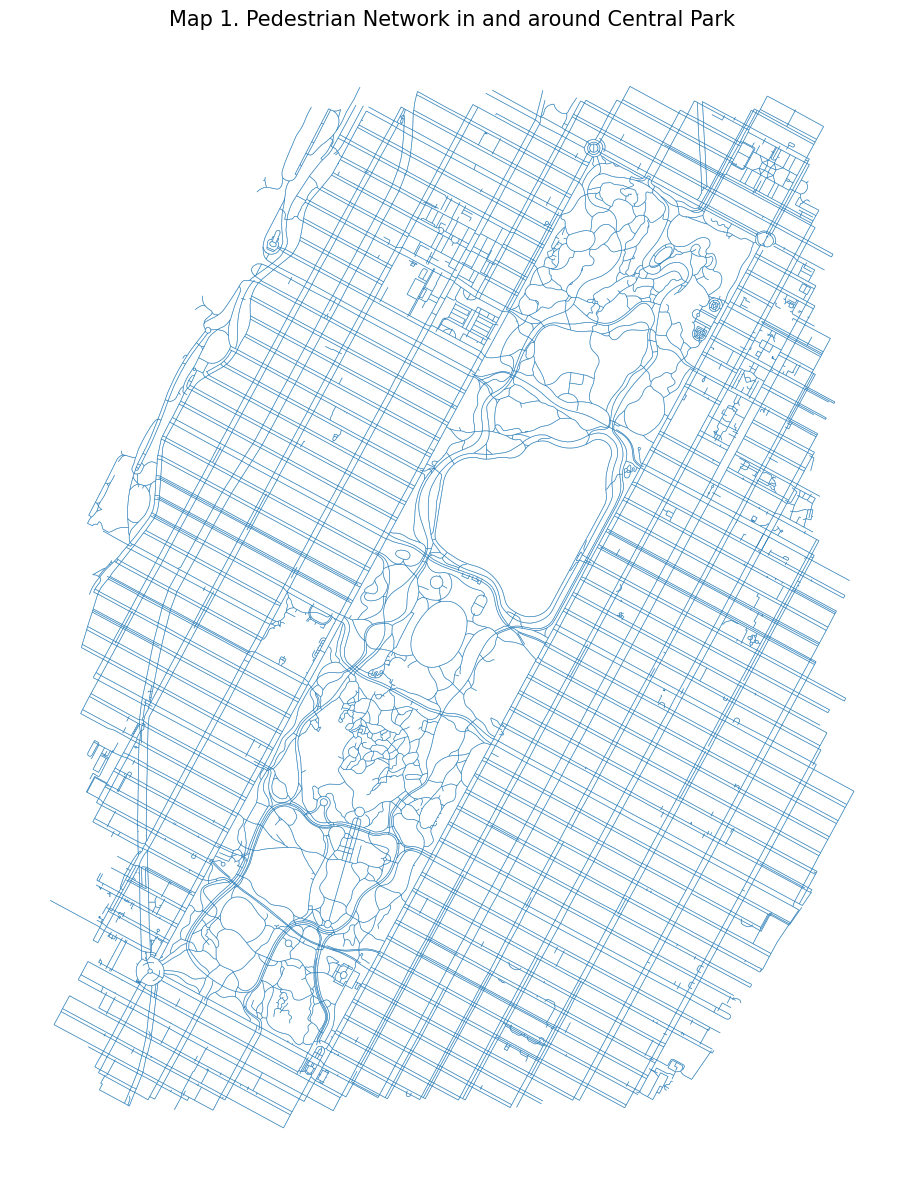

In [6]:

fig, ax = plt.subplots(figsize=(10, 12))

edges_proj.plot(
    ax=ax,
    linewidth=0.45,
    alpha=0.65,
)

ax.set_title("Map 1. Pedestrian Network in and around Central Park", fontsize=15)
ax.set_axis_off()
plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "01_pedestrian_network.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()



## 5. Matching the Attractions to Network Nodes

Points representing attractions do not always fall exactly on a mapped path. Therefore, each origin or destination point is matched to the nearest graph node.

Two distances are reported:

- **origin snap distance:** distance from the exact origin point to its nearest network node;
- **destination snap distance:** distance from the exact attraction point to its nearest network node.

Large snap distances may indicate that a coordinate represents the middle of a lawn, building, bridge, or broad attraction rather than a path entrance. These values should be checked before interpreting the final routes.


In [7]:

# Project the points into the same CRS as the network.
origin_proj = origin_gdf.to_crs(G_proj.graph["crs"])
destinations_proj = destinations_gdf.to_crs(G_proj.graph["crs"])

# Find nearest graph node for origin.
origin_node, origin_snap_distance = ox.distance.nearest_nodes(
    G_proj,
    X=float(origin_proj.geometry.x.iloc[0]),
    Y=float(origin_proj.geometry.y.iloc[0]),
    return_dist=True,
)

# Find nearest graph node for every destination.
destination_nodes, destination_snap_distances = ox.distance.nearest_nodes(
    G_proj,
    X=destinations_proj.geometry.x.to_numpy(),
    Y=destinations_proj.geometry.y.to_numpy(),
    return_dist=True,
)

destinations_proj = destinations_proj.copy()
destinations_proj["network_node"] = destination_nodes
destinations_proj["snap_distance_m"] = destination_snap_distances

print(f"Origin snap distance: {origin_snap_distance:.1f} m")
display(
    destinations_proj[
        ["name", "category", "network_node", "snap_distance_m"]
    ].sort_values("snap_distance_m", ascending=False)
)

# Warn about locations that are relatively far from the nearest mapped path.
large_snap = destinations_proj[destinations_proj["snap_distance_m"] > 100]
if len(large_snap):
    print(
        "\nReview these locations because their point is more than 100 m "
        "from the nearest network node:"
    )
    display(large_snap[["name", "snap_distance_m"]])
else:
    print("\nAll destination snap distances are 100 m or less.")


Origin snap distance: 82.6 m


,name,category,network_node,snap_distance_m
5,Bow Bridge,Bridge,480493125,54.24
2,The Ramble,Landscape,4254403623,43.81
11,Conservatory Garden,Garden,600524142,29.76
9,Sheep Meadow,Landscape,561949963,14.41
0,Obelisk (Cleopatra's Needle),Monument,4290878455,12.43
3,Alice in Wonderland,Monument,1901016095,10.97
6,Bethesda Terrace and Fountain,Architecture,561950188,8.81
4,Conservatory Water,Water,4246691929,7.81
8,The Mall and Literary Walk,Promenade,3248816714,7.66
7,Strawberry Fields / Imagine Mosaic,Memorial,3248816681,6.73



All destination snap distances are 100 m or less.



## Map 2 — Selected Attractions and Their Network Connections

The line segments on this map connect each exact attraction point to the node used for routing. This is a validation map rather than a final analytical result. It helps reveal whether a point has been matched to an unreasonable path.


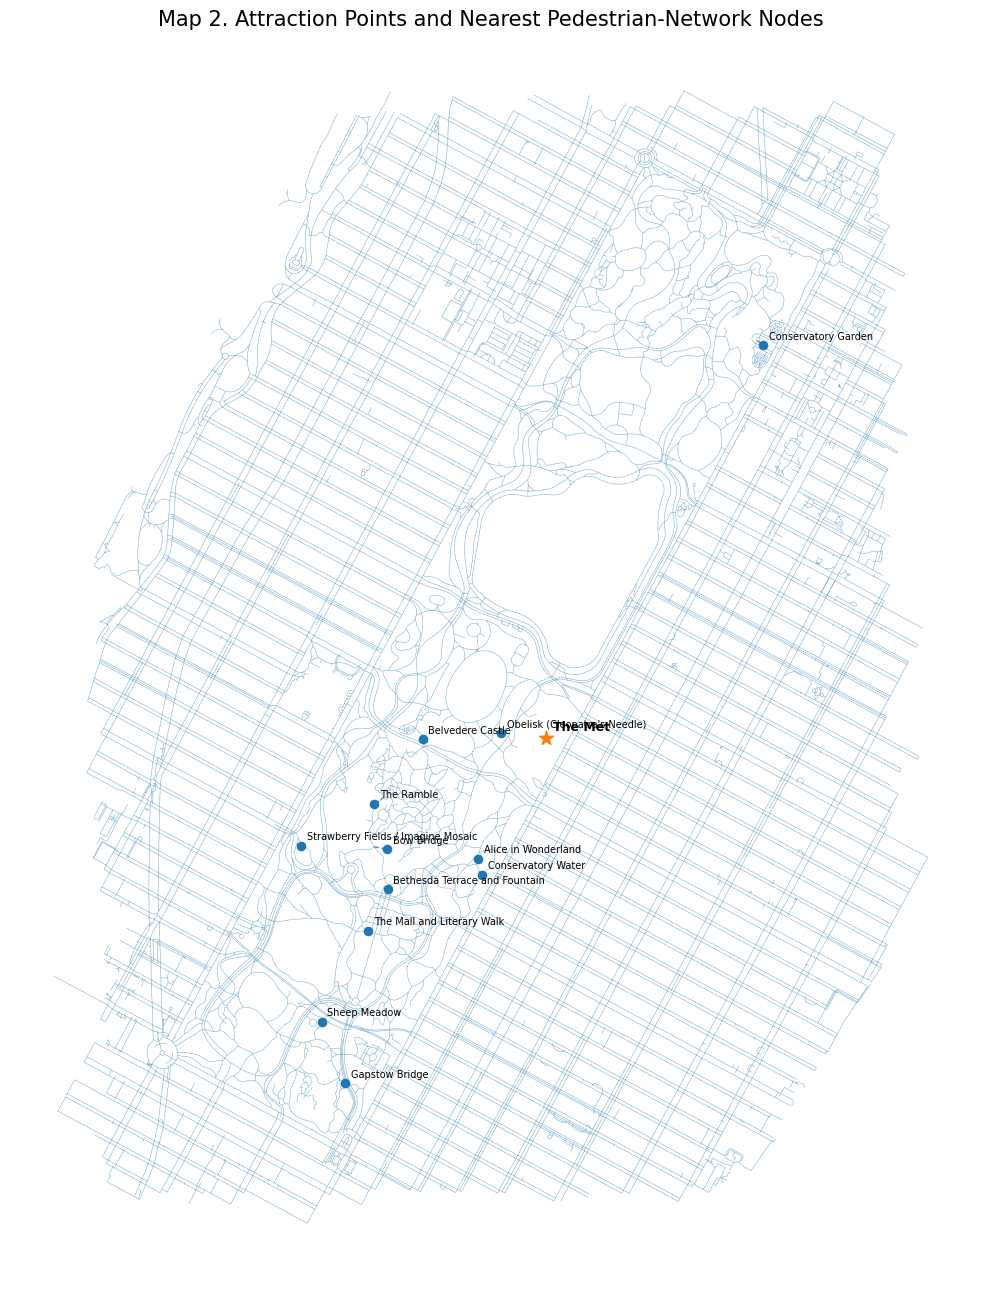

In [8]:

origin_node_point = Point(
    G_proj.nodes[origin_node]["x"],
    G_proj.nodes[origin_node]["y"],
)

destination_node_points = [
    Point(G_proj.nodes[node]["x"], G_proj.nodes[node]["y"])
    for node in destinations_proj["network_node"]
]

snap_lines = [
    LineString([poi_point, node_point])
    for poi_point, node_point in zip(
        destinations_proj.geometry,
        destination_node_points,
    )
]

snap_lines_gdf = gpd.GeoDataFrame(
    destinations_proj[["name"]].copy(),
    geometry=snap_lines,
    crs=G_proj.graph["crs"],
)

fig, ax = plt.subplots(figsize=(11, 13))

edges_proj.plot(ax=ax, linewidth=0.35, alpha=0.35)
snap_lines_gdf.plot(ax=ax, linewidth=1.0, linestyle="--", alpha=0.8)
destinations_proj.plot(ax=ax, markersize=35)
origin_proj.plot(ax=ax, markersize=110, marker="*")

for _, row in destinations_proj.iterrows():
    ax.annotate(
        row["name"],
        (row.geometry.x, row.geometry.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=7,
    )

ax.annotate(
    "The Met",
    (
        origin_proj.geometry.x.iloc[0],
        origin_proj.geometry.y.iloc[0],
    ),
    xytext=(5, 5),
    textcoords="offset points",
    fontsize=9,
    fontweight="bold",
)

ax.set_title("Map 2. Attraction Points and Nearest Pedestrian-Network Nodes", fontsize=15)
ax.set_axis_off()
plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "02_node_validation.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()



## 6. Calculating Euclidean and Network Distance

### Euclidean distance

Euclidean distance is calculated between the exact projected origin point and each exact projected destination point.

### Pedestrian network distance

For each destination, NetworkX calculates the length-weighted shortest path between the origin node and destination node.

To avoid ignoring the short gap between a point and its matched node, the reported network distance includes:

network total= origin snap+shortest path+destination snap

### Detour ratio

Detour Ratio =Network Distance/Euclidean Distance
- A value close to **1.0** means the pedestrian route is relatively direct.
- A higher value means the network requires a greater proportional detour.

### Additional walking distance

Additional Distance =
Network Distance - Euclidean Distance


In [9]:

def route_to_gdf(graph, route):
    """Convert a node route in a projected MultiDiGraph to edge geometries."""
    records = []

    for u, v in zip(route[:-1], route[1:]):
        edge_options = graph.get_edge_data(u, v)

        if edge_options is None:
            raise ValueError(f"No edge found between route nodes {u} and {v}.")

        # Select the shortest parallel edge when more than one edge connects u and v.
        selected_key = min(
            edge_options,
            key=lambda key: edge_options[key].get("length", np.inf),
        )
        edge_data = edge_options[selected_key]

        geometry = edge_data.get(
            "geometry",
            LineString(
                [
                    (graph.nodes[u]["x"], graph.nodes[u]["y"]),
                    (graph.nodes[v]["x"], graph.nodes[v]["y"]),
                ]
            ),
        )

        records.append(
            {
                "u": u,
                "v": v,
                "key": selected_key,
                "length": edge_data.get("length", geometry.length),
                "geometry": geometry,
            }
        )

    return gpd.GeoDataFrame(
        records,
        geometry="geometry",
        crs=graph.graph["crs"],
    )


origin_point = origin_proj.geometry.iloc[0]
route_records = []
route_gdfs = {}

for _, destination in destinations_proj.iterrows():
    destination_node = destination["network_node"]

    route = nx.shortest_path(
        G_proj,
        source=origin_node,
        target=destination_node,
        weight="length",
    )

    route_gdf = route_to_gdf(G_proj, route)
    route_gdfs[destination["name"]] = route_gdf

    shortest_path_distance = route_gdf["length"].sum()
    euclidean_distance = origin_point.distance(destination.geometry)

    total_network_distance = (
        float(origin_snap_distance)
        + shortest_path_distance
        + float(destination["snap_distance_m"])
    )

    route_records.append(
        {
            "destination": destination["name"],
            "category": destination["category"],
            "euclidean_distance_m": euclidean_distance,
            "shortest_path_edges_m": shortest_path_distance,
            "origin_snap_m": float(origin_snap_distance),
            "destination_snap_m": float(destination["snap_distance_m"]),
            "network_distance_m": total_network_distance,
            "additional_distance_m": total_network_distance - euclidean_distance,
            "detour_ratio": total_network_distance / euclidean_distance,
            "estimated_walk_time_min": total_network_distance / 80.0,
            "route_node_count": len(route),
        }
    )

results = pd.DataFrame(route_records).sort_values(
    "network_distance_m"
).reset_index(drop=True)

results["euclidean_distance_km"] = results["euclidean_distance_m"] / 1000
results["network_distance_km"] = results["network_distance_m"] / 1000
results["additional_distance_km"] = results["additional_distance_m"] / 1000

display(
    results[
        [
            "destination",
            "category",
            "euclidean_distance_m",
            "network_distance_m",
            "additional_distance_m",
            "detour_ratio",
            "estimated_walk_time_min",
        ]
    ].round(2)
)

results.to_csv(
    OUTPUT_DIR / "the_met_central_park_distance_results.csv",
    index=False,
)


,destination,category,euclidean_distance_m,network_distance_m,additional_distance_m,detour_ratio,estimated_walk_time_min
0,Obelisk (Cleopatra's Needle),Monument,185.05,699.01,513.96,3.78,8.74
1,Alice in Wonderland,Monument,563.96,706.32,142.36,1.25,8.83
2,Conservatory Water,Water,614.45,748.42,133.97,1.22,9.36
3,Belvedere Castle,Architecture,501.27,944.98,443.71,1.89,11.81
4,Bethesda Terrace and Fountain,Architecture,890.01,"1,102.78",212.77,1.24,13.78
5,The Ramble,Landscape,747.85,"1,213.06",465.21,1.62,15.16
6,Bow Bridge,Bridge,789.07,"1,310.88",521.81,1.66,16.39
7,The Mall and Literary Walk,Promenade,"1,066.56","1,326.98",260.42,1.24,16.59
8,Strawberry Fields / Imagine Mosaic,Memorial,"1,086.34","1,568.39",482.06,1.44,19.60
9,Sheep Meadow,Landscape,"1,469.88","1,745.86",275.99,1.19,21.82



## Map 3 — Euclidean Connections

This map represents geographic proximity as a set of straight lines. It ignores buildings, lakes, lawns, path direction, crossings, and terrain.


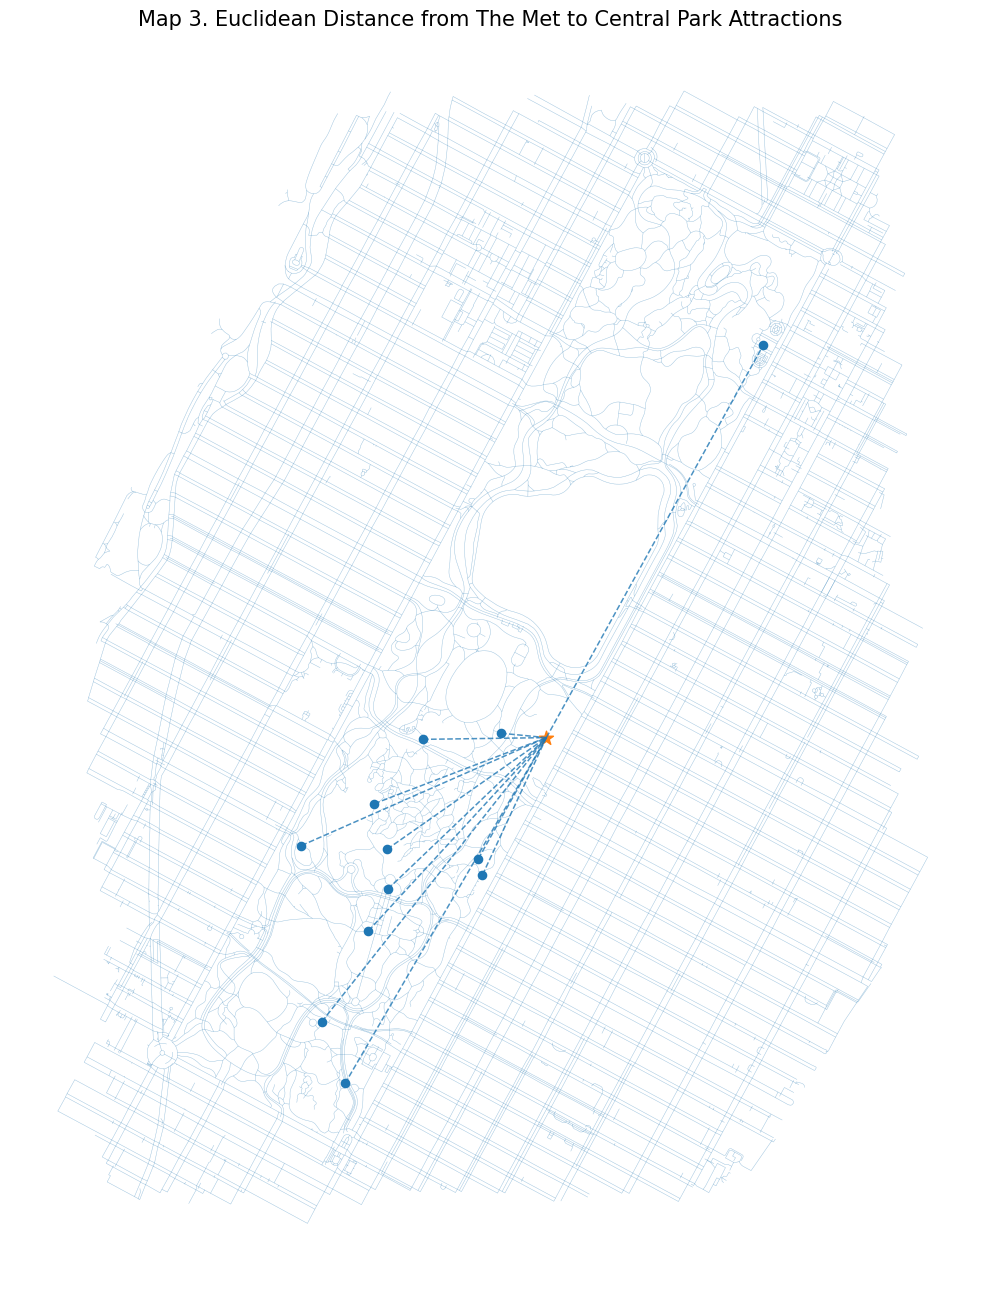

In [10]:

euclidean_lines = [
    LineString([origin_point, destination_geometry])
    for destination_geometry in destinations_proj.geometry
]

euclidean_gdf = gpd.GeoDataFrame(
    destinations_proj[["name"]].copy(),
    geometry=euclidean_lines,
    crs=G_proj.graph["crs"],
)

fig, ax = plt.subplots(figsize=(11, 13))

edges_proj.plot(ax=ax, linewidth=0.3, alpha=0.25)
euclidean_gdf.plot(ax=ax, linewidth=1.1, linestyle="--", alpha=0.8)
destinations_proj.plot(ax=ax, markersize=35)
origin_proj.plot(ax=ax, markersize=110, marker="*")

ax.set_title("Map 3. Euclidean Distance from The Met to Central Park Attractions", fontsize=15)
ax.set_axis_off()
plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "03_euclidean_connections.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()



## Map 4 — Shortest Pedestrian Routes

Unlike the previous map, these lines must follow connected pedestrian-network edges. Shared segments reveal where multiple trips depend on the same entrances or circulation corridors.


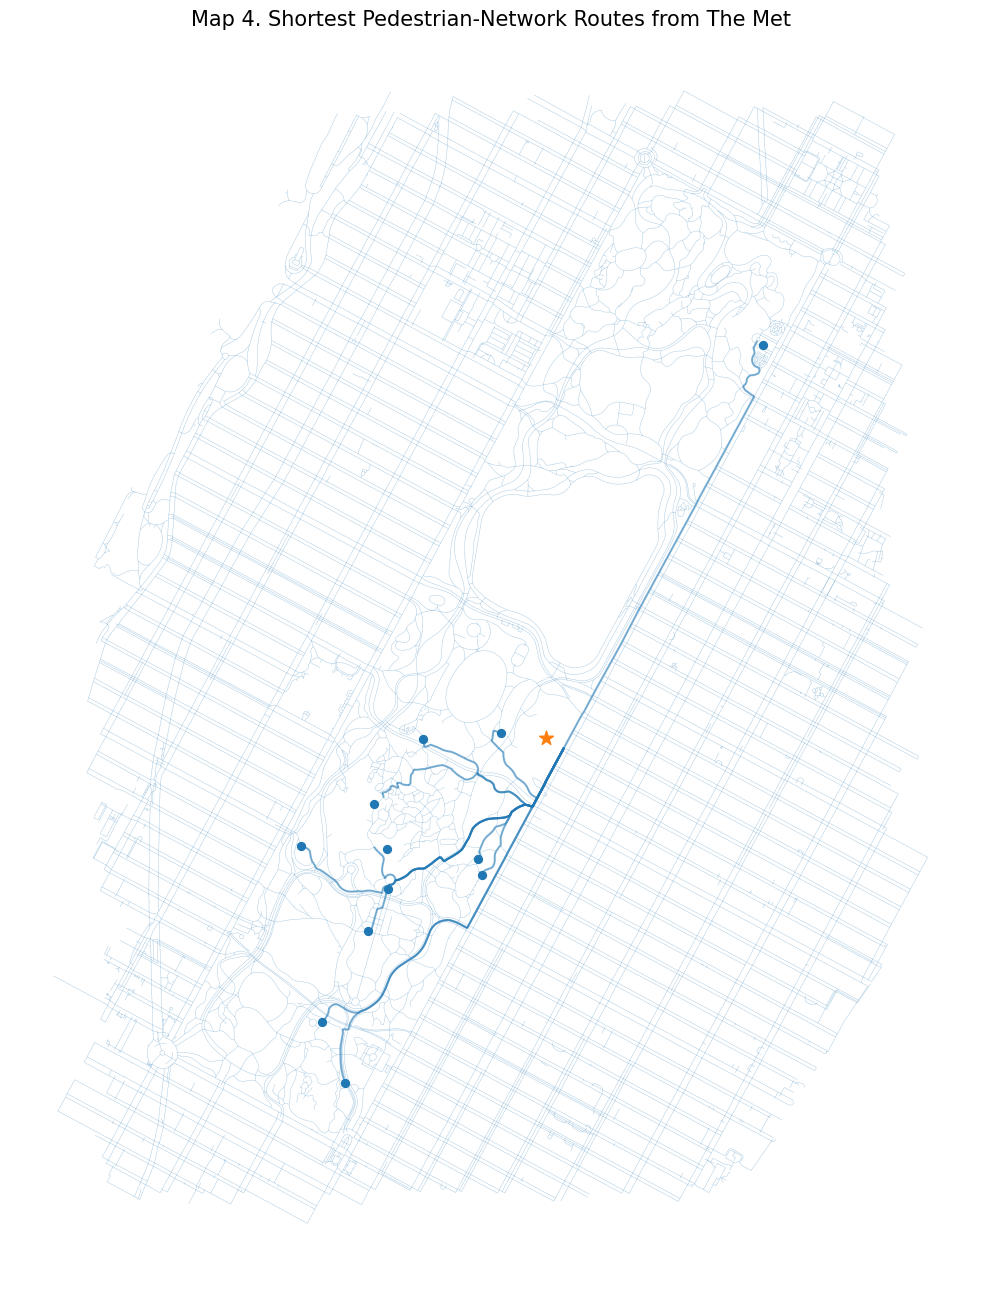

In [11]:

fig, ax = plt.subplots(figsize=(11, 13))

edges_proj.plot(ax=ax, linewidth=0.3, alpha=0.22)

for destination_name, route_gdf in route_gdfs.items():
    route_gdf.plot(ax=ax, linewidth=1.5, alpha=0.55)

destinations_proj.plot(ax=ax, markersize=32)
origin_proj.plot(ax=ax, markersize=110, marker="*")

ax.set_title("Map 4. Shortest Pedestrian-Network Routes from The Met", fontsize=15)
ax.set_axis_off()
plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "04_all_shortest_routes.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()



## Map 5 — Direct and Indirect Route Examples

To prevent the map from becoming unreadable, this comparison selects:

1. the destination with the **lowest detour ratio**;
2. the destination with the **highest detour ratio**;
3. the destination with the **greatest absolute additional distance**.

A destination can rank differently by proportional detour and absolute extra distance. For example, a nearby attraction may have a high ratio even if the number of additional meters is modest.


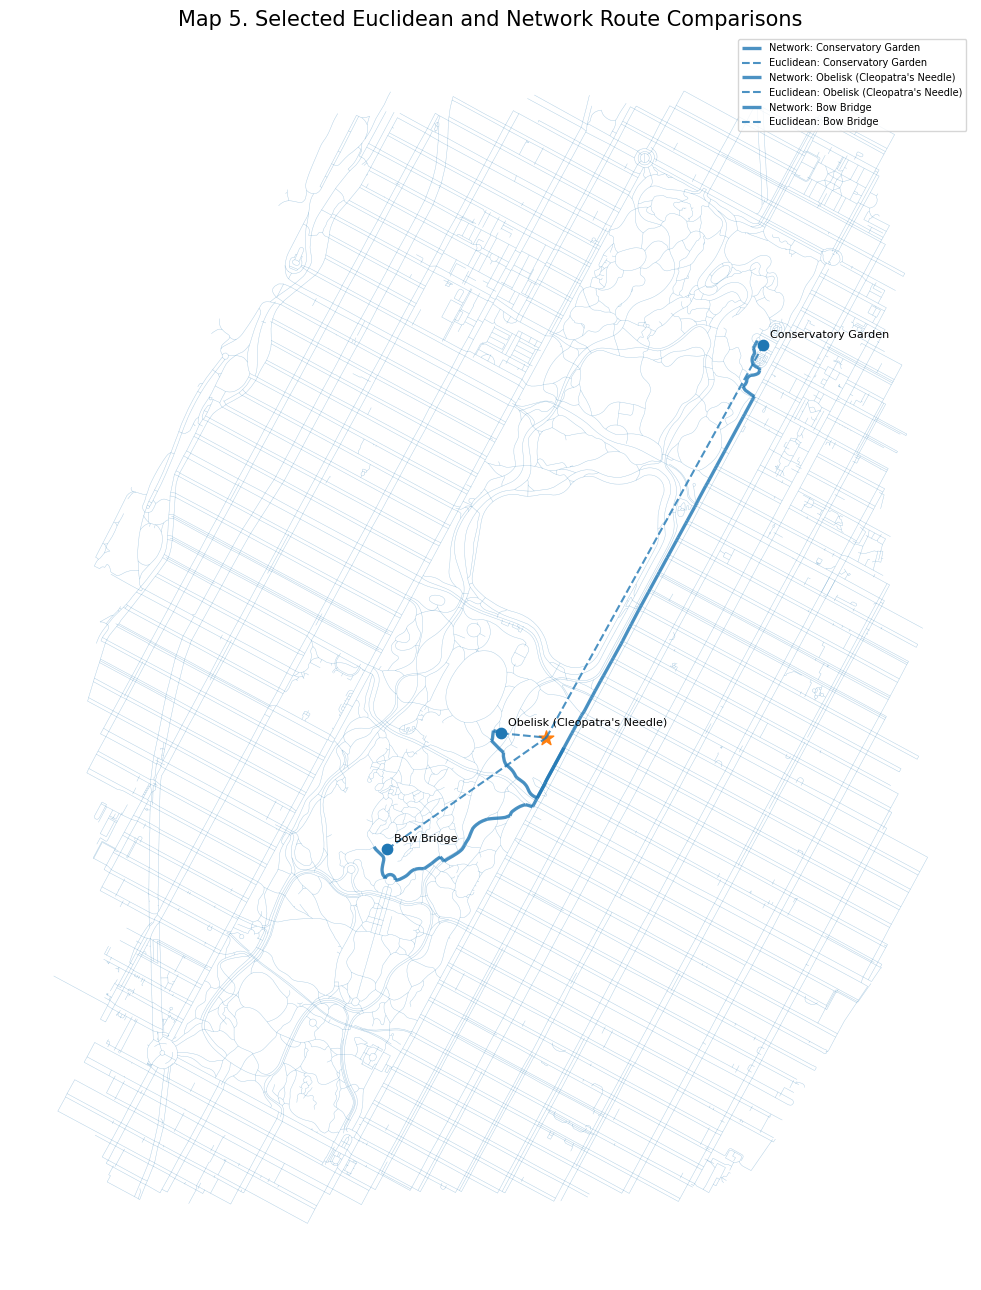

Lowest detour ratio: Conservatory Garden
Highest detour ratio: Obelisk (Cleopatra's Needle)
Largest absolute additional distance: Bow Bridge


In [12]:

lowest_ratio_name = results.nsmallest(1, "detour_ratio")["destination"].iloc[0]
highest_ratio_name = results.nlargest(1, "detour_ratio")["destination"].iloc[0]
largest_extra_name = results.nlargest(1, "additional_distance_m")["destination"].iloc[0]

selected_names = list(
    dict.fromkeys(
        [
            lowest_ratio_name,
            highest_ratio_name,
            largest_extra_name,
        ]
    )
)

fig, ax = plt.subplots(figsize=(11, 13))
edges_proj.plot(ax=ax, linewidth=0.3, alpha=0.2)

for destination_name in selected_names:
    route_gdfs[destination_name].plot(
        ax=ax,
        linewidth=2.4,
        alpha=0.8,
        label=f"Network: {destination_name}",
    )

    destination_point = destinations_proj.loc[
        destinations_proj["name"] == destination_name,
        "geometry",
    ].iloc[0]

    gpd.GeoSeries(
        [LineString([origin_point, destination_point])],
        crs=G_proj.graph["crs"],
    ).plot(
        ax=ax,
        linewidth=1.5,
        linestyle="--",
        alpha=0.8,
        label=f"Euclidean: {destination_name}",
    )

selected_points = destinations_proj[
    destinations_proj["name"].isin(selected_names)
]

selected_points.plot(ax=ax, markersize=55)
origin_proj.plot(ax=ax, markersize=120, marker="*")

for _, row in selected_points.iterrows():
    ax.annotate(
        row["name"],
        (row.geometry.x, row.geometry.y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Map 5. Selected Euclidean and Network Route Comparisons", fontsize=15)
ax.set_axis_off()
ax.legend(loc="best", fontsize=7)
plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "05_selected_route_comparisons.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Lowest detour ratio:", lowest_ratio_name)
print("Highest detour ratio:", highest_ratio_name)
print("Largest absolute additional distance:", largest_extra_name)



## Chart 1 — Euclidean Distance vs. Network Distance

The paired bars show how much straight-line distance underestimates the actual shortest walk for each attraction.


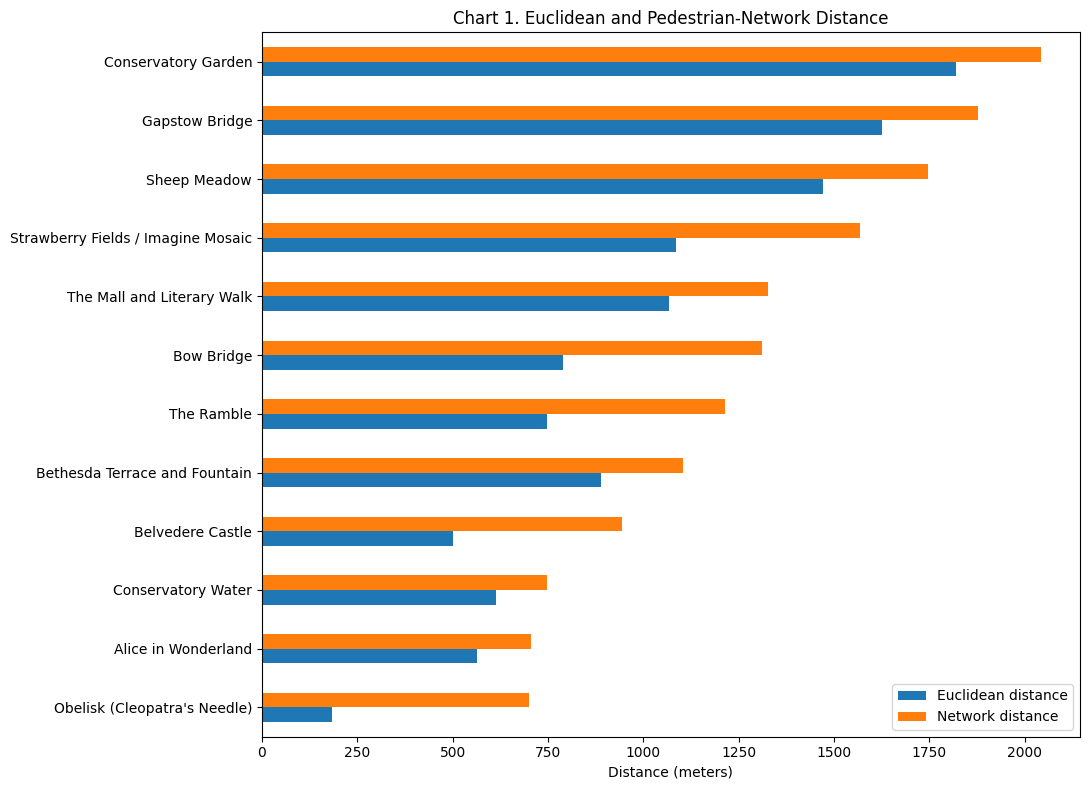

In [13]:

chart_data = (
    results.set_index("destination")[
        ["euclidean_distance_m", "network_distance_m"]
    ]
    .sort_values("network_distance_m")
)

ax = chart_data.plot(
    kind="barh",
    figsize=(11, 8),
)

ax.set_title("Chart 1. Euclidean and Pedestrian-Network Distance")
ax.set_xlabel("Distance (meters)")
ax.set_ylabel("")
ax.legend(["Euclidean distance", "Network distance"])
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "06_distance_comparison_chart.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()



## Chart 2 — Detour Ratio Ranking

The detour ratio normalizes for the fact that some destinations are farther away than others. It is therefore useful for identifying destinations whose route is unusually indirect relative to their apparent proximity.


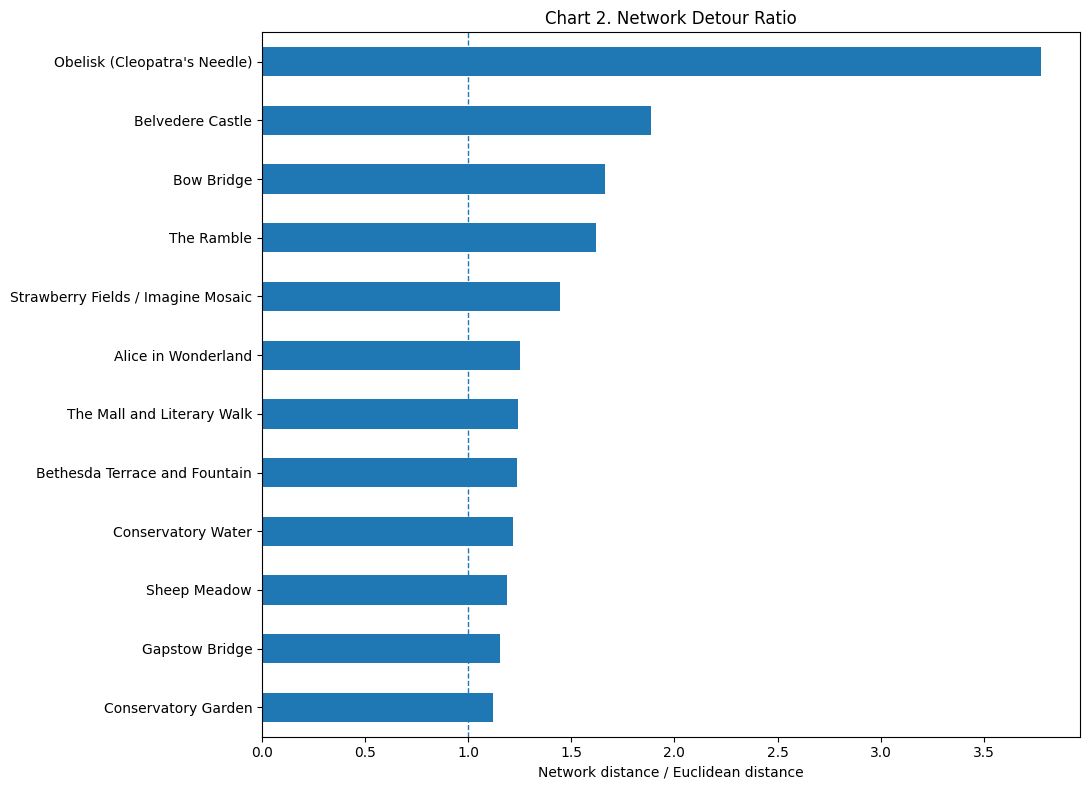

In [14]:

ratio_data = results.sort_values("detour_ratio").set_index("destination")

ax = ratio_data["detour_ratio"].plot(
    kind="barh",
    figsize=(11, 8),
)

ax.axvline(1.0, linestyle="--", linewidth=1)
ax.set_title("Chart 2. Network Detour Ratio")
ax.set_xlabel("Network distance / Euclidean distance")
ax.set_ylabel("")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "07_detour_ratio_chart.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()



## Chart 3 — Relationship Between Euclidean and Network Distance

If the path network allowed perfectly direct travel, every attraction would lie on the `y = x` reference line. Points above the line require additional travel. The vertical distance from the reference line represents the extra distance produced by network structure.


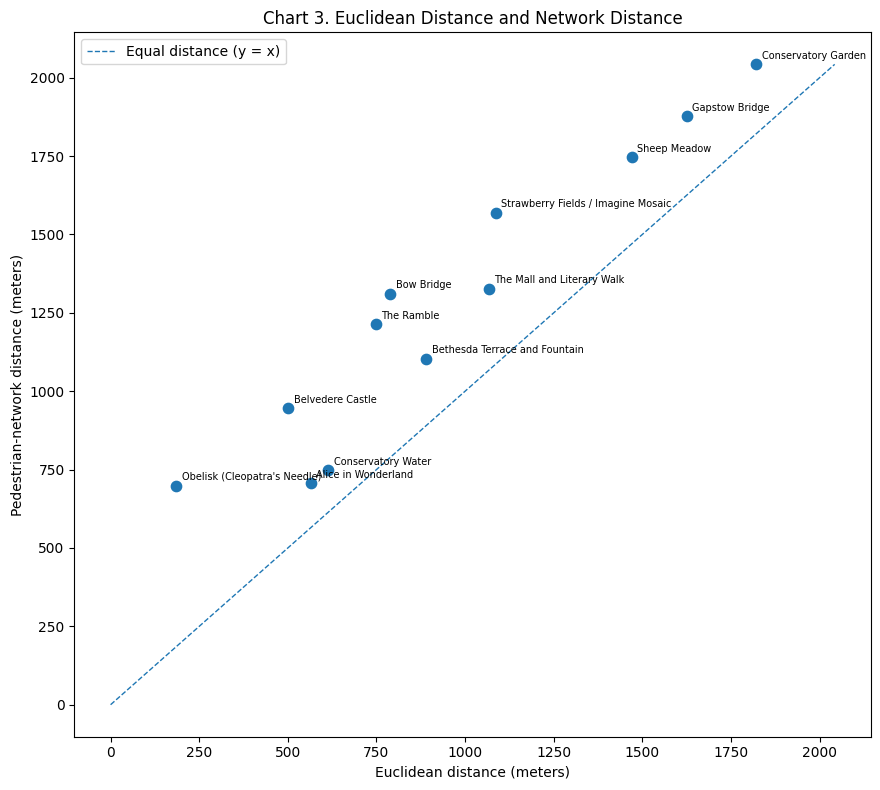

In [15]:

fig, ax = plt.subplots(figsize=(9, 8))

ax.scatter(
    results["euclidean_distance_m"],
    results["network_distance_m"],
    s=55,
)

maximum_distance = results[
    ["euclidean_distance_m", "network_distance_m"]
].to_numpy().max()

ax.plot(
    [0, maximum_distance],
    [0, maximum_distance],
    linestyle="--",
    linewidth=1,
    label="Equal distance (y = x)",
)

for _, row in results.iterrows():
    ax.annotate(
        row["destination"],
        (
            row["euclidean_distance_m"],
            row["network_distance_m"],
        ),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=7,
    )

ax.set_title("Chart 3. Euclidean Distance and Network Distance")
ax.set_xlabel("Euclidean distance (meters)")
ax.set_ylabel("Pedestrian-network distance (meters)")
ax.legend()
plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "08_distance_scatterplot.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()



## 7. Results Summary




In [16]:

highest_ratio = results.nlargest(1, "detour_ratio").iloc[0]
lowest_ratio = results.nsmallest(1, "detour_ratio").iloc[0]
largest_extra = results.nlargest(1, "additional_distance_m").iloc[0]
longest_route = results.nlargest(1, "network_distance_m").iloc[0]
shortest_route = results.nsmallest(1, "network_distance_m").iloc[0]

print("KEY FINDINGS\n")

print(
    f"1. {highest_ratio['destination']} has the highest detour ratio "
    f"({highest_ratio['detour_ratio']:.2f}). Its shortest walking route is "
    f"{highest_ratio['network_distance_m']:.0f} m, compared with a "
    f"{highest_ratio['euclidean_distance_m']:.0f} m straight-line distance."
)

print(
    f"2. {lowest_ratio['destination']} has the most direct relationship to "
    f"The Met, with a detour ratio of {lowest_ratio['detour_ratio']:.2f}."
)

print(
    f"3. {largest_extra['destination']} adds the greatest absolute distance: "
    f"approximately {largest_extra['additional_distance_m']:.0f} m beyond "
    f"its Euclidean distance."
)

print(
    f"4. The longest shortest-path trip is to {longest_route['destination']} "
    f"at approximately {longest_route['network_distance_m']:.0f} m "
    f"({longest_route['estimated_walk_time_min']:.1f} estimated minutes)."
)

print(
    f"5. The shortest trip is to {shortest_route['destination']} at "
    f"approximately {shortest_route['network_distance_m']:.0f} m."
)

print(
    f"6. Across all destinations, the mean detour ratio is "
    f"{results['detour_ratio'].mean():.2f}, and the median is "
    f"{results['detour_ratio'].median():.2f}."
)


KEY FINDINGS

1. Obelisk (Cleopatra's Needle) has the highest detour ratio (3.78). Its shortest walking route is 699 m, compared with a 185 m straight-line distance.
2. Conservatory Garden has the most direct relationship to The Met, with a detour ratio of 1.12.
3. Bow Bridge adds the greatest absolute distance: approximately 522 m beyond its Euclidean distance.
4. The longest shortest-path trip is to Conservatory Garden at approximately 2043 m (25.5 estimated minutes).
5. The shortest trip is to Obelisk (Cleopatra's Needle) at approximately 699 m.
6. Across all destinations, the mean detour ratio is 1.57, and the median is 1.25.
